<a href="https://colab.research.google.com/github/Biilzaa/TugasPraktikum1---AI/blob/main/PraktikumMandiriRegresiLinearSederhana.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Tahap 1: Inisialisasi LibraryDilakukan pemanggilan modul-modul utama yang diperlukan untuk analisis data. Pandas digunakan untuk manipulasi dataframe, Matplotlib untuk visualisasi grafis, dan Scikit-Learn untuk implementasi algoritma Regresi Linear serta perhitungan metrik evaluasi.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics

Tahap 2: Konstruksi Dataset

Dataset disusun untuk memodelkan hubungan antara biaya pemasaran (iklan) dan volume unduhan aplikasi sebagai variabel dependen.

In [22]:
data = {
    'biaya_iklan': [2, 3.5, 4, 5.5, 7, 8.5, 9, 10.5, 12, 15],
    'unduhan': [10, 14, 18, 25, 30, 38, 40, 48, 55, 65]
}

df = pd.DataFrame(data)
print(df)

   biaya_iklan  unduhan
0          2.0       10
1          3.5       14
2          4.0       18
3          5.5       25
4          7.0       30
5          8.5       38
6          9.0       40
7         10.5       48
8         12.0       55
9         15.0       65


Tahap 3: Spesifikasi Variabel Independen dan DependenVariabel biaya_iklan didefinisikan sebagai fitur (X) dan variabel unduhan sebagai target (y) sesuai dengan prinsip regresi linear sederhana.

In [23]:
X = df[['biaya_iklan']]
y = df['unduhan']

Tahap 4: Partisi Data Training dan Data Testing

Data dibagi menjadi dua bagian untuk memastikan validitas model: 80% digunakan untuk proses pelatihan (training) dan 20% digunakan untuk pengujian (testing).

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Tahap 5: Implementasi dan Pelatihan Model

Proses pelatihan dilakukan menggunakan algoritma LinearRegression untuk menemukan koefisien optimal yang meminimalkan nilai error.

In [25]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Tahap 6: Analisis Parameter Model (Intercept & Koefisien)Nilai Intercept menunjukkan nilai dasar target saat variabel independen bernilai nol, sedangkan Koefisien menunjukkan besarnya perubahan target untuk setiap satu satuan perubahan pada fitur.

In [26]:
print("Intercept (a):", model.intercept_)
print("Koefisien (b):", model.coef_[0])

Intercept (a): 1.1429736341397216
Koefisien (b): 4.306605055721662


Tahap 7: Eksekusi Prediksi pada Data Testing

Model yang telah dilatih diterapkan pada data pengujian untuk mengevaluasi kemampuan generalisasi model terhadap data yang belum pernah dilihat sebelumnya.

In [27]:
y_pred = model.predict(X_test)

print("Data Testing:")
print(X_test)
print("Unduhan Asli:", y_test.values)
print("Unduhan Prediksi:", y_pred)

Data Testing:
   biaya_iklan
8         12.0
1          3.5
Unduhan Asli: [55 14]
Unduhan Prediksi: [52.8222343  16.21609133]


Tahap 8: Pengukuran Metrik Evaluasi RegresiEvaluasi kualitas model dilakukan dengan menghitung nilai Mean Absolute Error (MAE), Mean Squared Error (MSE), dan Root Mean Squared Error (RMSE).

In [28]:
print("MAE:", metrics.mean_absolute_error(y_test, y_pred))
print("MSE:", metrics.mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

MAE: 2.196928513182934
MSE: 4.826862105552561
RMSE: 2.1970120858913273


Tahap 9: Implementasi Prediksi Data Baru

Dilakukan simulasi prediksi terhadap observasi baru. Penggunaan pd.DataFrame memastikan konsistensi format input dan menghindari peringatan sistem (UserWarning).

In [29]:
data_baru = pd.DataFrame([[20]], columns=['biaya_iklan'])
prediksi = model.predict(data_baru)
print("Prediksi unduhan untuk biaya iklan 20 Juta:", prediksi[0])

Prediksi unduhan untuk biaya iklan 20 Juta: 87.27507474857296


Tahap 10: Visualisasi Garis RegresiVisualisasi dalam bentuk scatter plot dan garis regresi memberikan gambaran komprehensif mengenai keselarasan model dengan pola distribusi data asli.

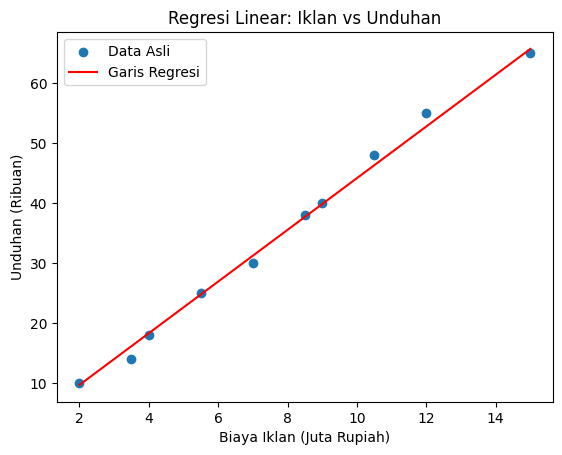

In [30]:
plt.scatter(X, y, label="Data Asli")
plt.plot(X, model.predict(X), label="Garis Regresi", color="red")
plt.xlabel("Biaya Iklan (Juta Rupiah)")
plt.ylabel("Unduhan (Ribuan)")
plt.title("Regresi Linear: Iklan vs Unduhan")
plt.legend()
plt.show()